In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
from scipy import linalg
from scipy.spatial.distance import cdist
import os
from PIL import Image
import math
import numpy as np

In [ ]:
def detectTag(folder_path, marker_size): 
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    aruco_detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    all_object_pts = []
    all_img_pts = []
    marker_size_in_world = np.array([
        [0,0,0], 
        [marker_size, 0, 0], 
        [marker_size, marker_size, 0],
        [0, marker_size, 0]], dtype=np.float32)
    image_size = None

    image_paths = glob.glob(os.path.join(folder_path, "*.jpg"))
    print(f"Found {len(image_paths)} images")


    
    for image_path in image_paths: 
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if image is None: 
            continue

        target_height = 300 
        height, width = image.shape[:2]
        if height > target_height:
            scale = target_height / height
            new_width = int(width * scale)
            new_height = target_height
            image = cv2.resize(image, (new_width, new_height))
        
        if image_size is None: 
            image_size = (image.shape[1], image.shape[0]) 

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        corners, ids, _ = aruco_detector.detectMarkers(gray)
        
        if ids is not None:
            for marker_corners in corners: 
                corners_2d = marker_corners.reshape(-1, 2)
                all_object_pts.append(marker_size_in_world)
                all_img_pts.append(corners_2d)
        else:
            print(f"No markers detected in {os.path.basename(image_path)}")

    print(f"Total markers collected: {len(all_object_pts)}")
    
    print("Starting calibration...")
    
    error, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        all_object_pts,  
        all_img_pts,  
        image_size,     
        None, None,
        flags=cv2.CALIB_USE_LU  
    )
    
    return camera_matrix, dist_coeffs, error

Found 44 images


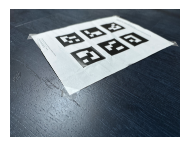

Total markers collected: 243
Starting calibration...
Camera Matrix:
 [[303.95713499   0.         194.72371481]
 [  0.         308.76975836 139.6174809 ]
 [  0.           0.           1.        ]]
Distortion Coefficients:
 [[ 3.59665264e-01 -2.49663473e+00 -1.03017658e-02  2.34846885e-03
   4.80043624e+00]]
Reprojection Error: 0.3608295360129861


In [18]:
folder_path = "./0.1/converted_jpgs"
marker_size = 0.05 
camera_matrix, dist_coeffs, error = detectTag(folder_path, marker_size)
print("Camera Matrix:\n", camera_matrix)
print("Distortion Coefficients:\n", dist_coeffs)
print("Reprojection Error:", error)


In [19]:
import sys
print(sys.executable)

c:\Users\isabe\cs\cs180\IHU3025.github.io\.venv\Scripts\python.exe


In [20]:
import viser
import numpy as np

In [21]:
def estimating_camera(folder_path, marker_size, camera_matrix, dist_coeffs): 
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    aruco_detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    all_matrix = []
    all_image = []
    all_size = []
    #intrisitc
   
    marker_size_in_world = np.array([
        [0,0,0], 
        [marker_size, 0, 0], 
        [marker_size, marker_size, 0],
        [0, marker_size, 0]], dtype=np.float32)
    

    image_paths = glob.glob(os.path.join(folder_path, "*.jpg"))
    print(f"Found {len(image_paths)} images")

    for image_path in image_paths: 
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if image is None: 
            continue

        target_height = 300 
        height, width = image.shape[:2]
        if height > target_height:
            scale = target_height / height
            new_width = int(width * scale)
            new_height = target_height
            image_resize = cv2.resize(image, (new_width, new_height))
        
        
        image_resize_size = (image_resize.shape[1], image_resize.shape[0]) 
        gray = cv2.cvtColor(image_resize, cv2.COLOR_BGR2GRAY)

        corners, ids, _ = aruco_detector.detectMarkers(gray)
        
        if ids is not None:
            this_obj_pts = []
            this_img_pts = [] 
            for marker_corners in corners: 
                corners_2d = marker_corners.reshape(-1, 2)
                this_obj_pts.append(marker_size_in_world)
                this_img_pts.append(corners_2d)
            success, rvec, tvec = cv2.solvePnP(
                np.array(this_obj_pts).reshape(-1, 1, 3), 
                np.array(this_img_pts).reshape(-1, 1, 2),
                camera_matrix, dist_coeffs)
            if success: 
                R, _ = cv2.Rodrigues(rvec)
                Rt = np.hstack((R, tvec)) 
                w2c = np.vstack((Rt, np.array([0, 0, 0, 1])))
                c2w = np.linalg.inv(w2c)
                all_matrix.append(c2w)
                all_image.append(image_resize)
                all_size.append(image_resize_size)
        else:
            print(f"No markers detected in {os.path.basename(image_path)}")
    return all_image, all_matrix, all_size
    

In [16]:
import time
def display_camera(all_image, all_matrix, all_size, K):
    server = viser.ViserServer(share=True)
    # Example of visualizing a camera frustum (in practice loop over all images)
    # c2w is the camera-to-world transformation matrix (3x4), and K is the camera intrinsic matrix (3x3)
    for i in range(len(all_image)): 
        H = all_size[i][1]
        W = all_size[i][0]
        c2w = all_matrix[i]
        img = all_image[i]
        server.scene.add_camera_frustum(
            f"/cameras/{i}", # give it a name
            fov=2 * np.arctan2(H / 2, K[0, 0]), # field of view
            aspect=W / H, # aspect ratio
            scale=0.02, # scale of the camera frustum change if too small/big
            wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz, # orientation in quaternion format
            position=c2w[:3, 3], # position of the camera
            image=img # image to visualize
        )

    while True:
        time.sleep(0.1)  # Wait to allow visualization to run

In [22]:
folder_path = "./0.2/converted_jpgs"
all_image, all_matrix, all_size = estimating_camera(folder_path, 0.05, camera_matrix, dist_coeffs)
display_camera(all_image, all_matrix, all_size, camera_matrix)

Found 69 images
No markers detected in IMG_9101.jpg
No markers detected in IMG_9106.jpg
No markers detected in IMG_9107.jpg
No markers detected in IMG_9108.jpg
No markers detected in IMG_9109.jpg
No markers detected in IMG_9112.jpg
No markers detected in IMG_9118.jpg
No markers detected in IMG_9120.jpg
No markers detected in IMG_9127.jpg
No markers detected in IMG_9131.jpg
No markers detected in IMG_9143.jpg
No markers detected in IMG_9145.jpg
No markers detected in IMG_9146.jpg
No markers detected in IMG_9147.jpg
No markers detected in IMG_9148.jpg
No markers detected in IMG_9149.jpg


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://forest-swim.share.viser.studio

(viser) Connection opened (0, 1 total), 218 persistent messages

(viser) Connection opened (1, 2 total), 218 persistent messages

KeyboardInterrupt: 

In [23]:
from sklearn.model_selection import train_test_split

def process_dataset(all_image, all_matrix, all_size, camera_matrix, dist_coeffs, 
                    output_path = 'my+data.npz'): 
    # Undistort an image using the calibration results
    undistorted_imgs = []
    for image in all_image: 
        undistorted_img = cv2.undistort(image, camera_matrix, dist_coeffs)
        undistorted_imgs.append(undistorted_img)

    image_array = np.array(undistorted_imgs) #(N, H, W , 3)
    c2w_array = np.array(all_matrix)    #(N, 4, 4)

    n_total = len(image_array)
    train_val_idx, test_idx = train_test_split(range(n_total), 
                                           test_size = 0.1, random_state= 42, shuffle= True)
    train_idx, val_idx = train_test_split(train_val_idx, 
                                          test_size = 0.11, random_state= 123, shuffle = True)
    
    #camera_matrix[[fx 0 cx] [0 fy cy] [0 0 1]]
    focal = camera_matrix[0][0]

    images_val = image_array[val_idx]
    images_train = image_array[train_idx]

    c2w_val = c2w_array[val_idx]
    c2ws_train = c2w_array[train_idx]
    c2w_test = c2w_array[test_idx]

    np.savez(
    output_path,
    images_train=images_train,    # (N_train, H, W, 3)
    c2ws_train=c2ws_train,        # (N_train, 4, 4)
    images_val=images_val,        # (N_val, H, W, 3)
    c2ws_val=c2w_val,            # (N_val, 4, 4)
    c2ws_test=c2w_test,          # (N_test, 4, 4)
    focal=focal                   # float
    )
    print(f"Dataset saved to {output_path}")
    print(f"Focal length: {focal}")
    

In [ ]:
process_dataset(all_image, all_matrix, all_size, camera_matrix, dist_coeffs, 'g1_rgb.npz')

Dataset saved to g1_rgb.npz
Focal length: 303.9571349938414


(viser) Connection closed (1, 1 total)

(viser) Connection closed (1, 1 total)

(viser) Connection closed (0, 0 total)

(viser) Connection closed (0, 0 total)

...

(viser) Connection closed (23, 0 total)

(viser) Connection opened (24, 1 total), 218 persistent messages

(viser) Connection opened (24, 1 total), 138 persistent messages

(viser) Connection opened (25, 2 total), 218 persistent messages

(viser) Connection opened (25, 2 total), 138 persistent messages